In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import date, timedelta

random.seed(42)

stages = ['App Install', 'Registration', 'Onboarding', 'First Purchase', 'Repeat Purchase']
users =  [10000, 6500, 4200, 1800, 750]

df_funnel = pd.DataFrame({'stage': stages, 'users': users})
df_funnel['drop_off_rate'] = df_funnel['users'].pct_change().round(3) * 100
df_funnel['conversion_rate'] = (df_funnel['users'] / df_funnel['users'].iloc[0] * 100).round(1)

print(df_funnel)

             stage  users  drop_off_rate  conversion_rate
0      App Install  10000            NaN            100.0
1     Registration   6500          -35.0             65.0
2       Onboarding   4200          -35.4             42.0
3   First Purchase   1800          -57.1             18.0
4  Repeat Purchase    750          -58.3              7.5


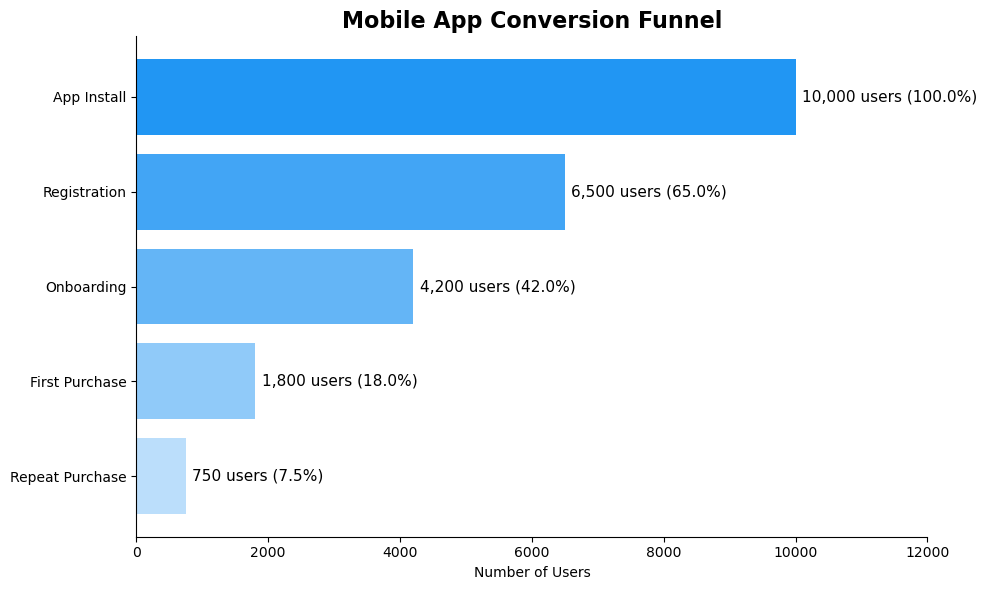

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB']

bars = ax.barh(df_funnel['stage'], df_funnel['users'], color=colors)

for bar, users, conv in zip(bars, df_funnel['users'], df_funnel['conversion_rate']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{users:,} users ({conv}%)', va='center', fontsize=11)

ax.set_xlabel('Number of Users')
ax.set_title('Mobile App Conversion Funnel', fontsize=16, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 12000)
sns.despine()

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()

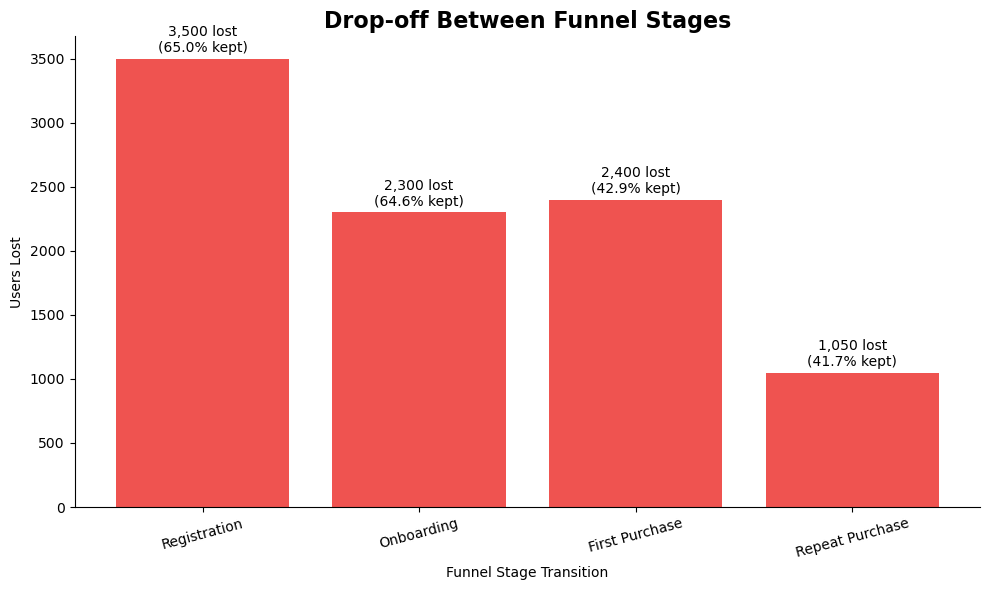

In [4]:
df_dropoff = df_funnel.copy()
df_dropoff['users_lost'] = df_funnel['users'].diff().abs()
df_dropoff['stage_conversion'] = (df_funnel['users'] / df_funnel['users'].shift(1) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_dropoff['stage'][1:], df_dropoff['users_lost'][1:], color='#EF5350')

for bar, val, conv in zip(bars, df_dropoff['users_lost'][1:], df_dropoff['stage_conversion'][1:]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(val):,} lost\n({conv}% kept)', ha='center', fontsize=10)

ax.set_xlabel('Funnel Stage Transition')
ax.set_ylabel('Users Lost')
ax.set_title('Drop-off Between Funnel Stages', fontsize=16, fontweight='bold')
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.savefig('dropoff_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import sqlite3

conn = sqlite3.connect('funnel.db')

conn.execute('''
CREATE TABLE IF NOT EXISTS funnel (
    stage TEXT,
    users INTEGER,
    conversion_rate REAL,
    drop_off_rate REAL
)
''')

conn.execute('DELETE FROM funnel')

for _, row in df_funnel.iterrows():
    conn.execute('INSERT INTO funnel VALUES (?, ?, ?, ?)',
                 (row['stage'], row['users'], row['conversion_rate'], row['drop_off_rate']))

conn.commit()

result = pd.read_sql_query('''
SELECT 
    stage,
    users,
    conversion_rate,
    ROUND(100 - conversion_rate, 1) AS overall_drop_off
FROM funnel
ORDER BY users DESC
''', conn)

print(result)
conn.close()

             stage  users  conversion_rate  overall_drop_off
0      App Install  10000            100.0               0.0
1     Registration   6500             65.0              35.0
2       Onboarding   4200             42.0              58.0
3   First Purchase   1800             18.0              82.0
4  Repeat Purchase    750              7.5              92.5


In [6]:
df_funnel.to_csv('funnel_data.csv', index=False)
print("Done")

Done
